In [42]:
import tensorflow
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.models import Sequential
import  pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



In [14]:
X_train = np.linspace(-1,1,20)
X_test=np.linspace(-1,1,20)
Y_train = np.random.uniform(-1,1,20)
Y_test = np.random.uniform(-1,1,20)


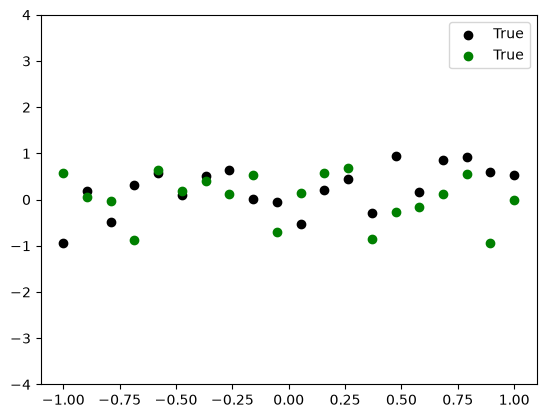

In [15]:
plt.scatter(X_train,Y_train,c='black',label=True)
plt.scatter(X_test,Y_test,c='green',label=True)
plt.ylim(-4,4)
plt.legend()

In [43]:
ES = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    baseline=None,
    mode='auto',
    restore_best_weights=True,
    verbose=1

)

In [51]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=1))
model.add(Dropout(0.7))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.57))
model.add(Dense(1,activation='linear'))
adam = Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam,metrics=['mse'])
history = model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=500,callbacks='')

Epoch 1/500


/Users/All file hear/complete ai /Deep learning/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - loss: 0.3369 - mse: 0.3369WARNING:tensorflow:5 out of the last 1009 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x16ccbaa20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step - loss: 0.3369 - mse: 0.3369 - val_loss: 0.2903 - val_mse: 0.2903
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2842 - mse: 0.2842 - val_loss: 0.3918 - val_mse: 0.3918
Epo

In [52]:
model.evaluate(X_train,Y_train)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1569 - mse: 0.1569


[0.15687906742095947, 0.15687906742095947]

In [53]:
model.evaluate(X_test,Y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4014 - mse: 0.4014


[0.4014464318752289, 0.4014464318752289]

In [54]:
Y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


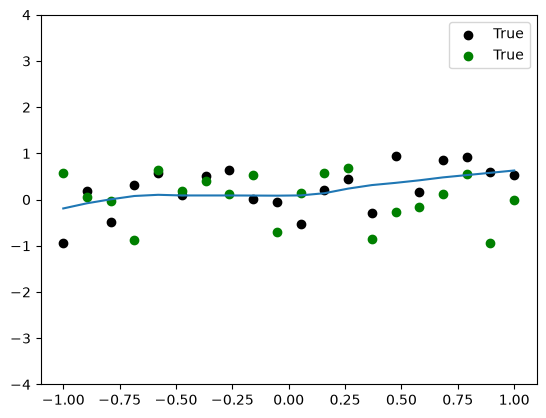

In [55]:
plt.scatter(X_train,Y_train,c='black',label=True)
plt.scatter(X_test,Y_test,c='green',label=True)
plt.plot(X_test,Y_pred)
plt.ylim(-4,4)
plt.legend()

(-2.0, 2.0)

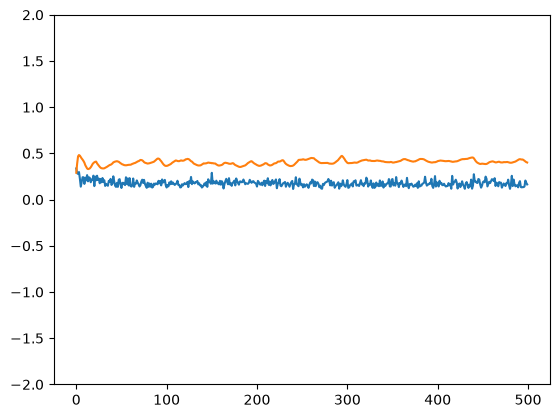

In [56]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylim(-2,2)